In [1]:

from concurrent.futures import ThreadPoolExecutor, as_completed
import os
import openai
import json
from threading import Lock
import pandas as pd
import re
import time
import nltk
import spacy
import numpy as np
from collections import Counter
from threading import local

# Load English tokenizer, POS tagger, parser, NER, and word vectors
nlp = spacy.load("en_core_web_sm")

# Define a word list using nltk corpus
english_vocab = set(w.lower() for w in nltk.corpus.words.words())

open_ai_keys = [
    os.getenv("OPENAI_KEY_1"),
    os.getenv("OPENAI_KEY_2"),
    os.getenv("OPENAI_KEY_3"),
    os.getenv("OPENAI_KEY_4"),
    os.getenv("OPENAI_KEY_5"),
    os.getenv("OPENAI_KEY_6"),
    os.getenv("OPENAI_KEY_7"),
    os.getenv("OPENAI_KEY_8"),
    os.getenv("OPENAI_KEY_9"),
    os.getenv("OPENAI_KEY_10"),
    os.getenv("OPENAI_KEY_11"),
    os.getenv("OPENAI_KEY_12"),
    os.getenv("OPENAI_KEY_13"),
    os.getenv("OPENAI_KEY_14"),
    os.getenv("OPENAI_KEY_15"),
    os.getenv("OPENAI_KEY_16"),
    os.getenv("OPENAI_KEY_17"),
    os.getenv("OPENAI_KEY_18"),
    os.getenv("OPENAI_KEY_19"),
    os.getenv("OPENAI_KEY_20"),
    os.getenv("OPENAI_KEY_21"),
    os.getenv("OPENAI_KEY_22"),
    os.getenv("OPENAI_KEY_23"),
    os.getenv("OPENAI_KEY_24"),
    os.getenv("OPENAI_KEY_25")
]

2023-06-16 19:48:16.823260: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
original_transcript_path = "../runs/2008-09-26-debate-preclean.txt"

In [3]:
def process_transcript(file_path, speakers_set):
    with open(file_path, 'r') as file:
        lines = file.readlines()

    # Initialize an empty list to store the speakers and their speeches
    processed_transcript = []

    # Initialize an empty string to store the current speaker
    current_speaker = ''

    for line in lines:
        # Remove leading and trailing whitespaces
        line = line.strip()

        if not line:
            continue

        # Split the line into speaker and speech, the maxsplit parameter is set to 1
        split_line = line.split(':', 1)

        # Check if the line could be split into speaker and speech
        if len(split_line) == 2:
            # Potential speaker
            potential_speaker = split_line[0].strip().upper()
            
            # If the potential speaker is in our known speakers set
            if potential_speaker in speakers_set:
                # Update the current speaker and append the speech to the transcript
                current_speaker, speech = split_line
                current_speaker = current_speaker.strip().upper()
                speech = speech.strip()
                
                processed_transcript.append((current_speaker, speech))
            else:
                # If the line could not be split into a valid speaker and speech, append it to the last speaker's last speech
                processed_transcript[-1] = (processed_transcript[-1][0], processed_transcript[-1][1] + ' ' + line)
        else:
            # If the line could not be split, append it to the last speaker's last speech
            processed_transcript[-1] = (processed_transcript[-1][0], processed_transcript[-1][1] + ' ' + line)

    # Create a dictionary to count speaker turns
    speaker_turns_dict = {speaker: sum(1 for t in processed_transcript if t[0] == speaker) for speaker in speakers_set}

    return processed_transcript, speaker_turns_dict

In [4]:
def write_transcript_to_file(transcript, output_path):
    with open(output_path, 'w') as file:
        for speaker_name, speaker_content in transcript:
            # Each line starts with the speaker name followed by their speech
            file.write(f'{speaker_name}: {speaker_content}\n')


In [5]:
known_speakers = {'LEHRER', 'OBAMA', 'MCCAIN'}

In [6]:
processed_transcript, speaker_turns_dict = process_transcript(original_transcript_path, known_speakers)

output_file_name = '2008-9-29-clean-final.txt'

write_transcript_to_file(processed_transcript, output_file_name)

In [7]:
def transcript_to_dataframe(processed_transcript):
    df = pd.DataFrame(processed_transcript, columns=['speaker', 'content'])
    return df

transcript_df = transcript_to_dataframe(processed_transcript)
print(type(transcript_df))
display(transcript_df)

<class 'pandas.core.frame.DataFrame'>


,speaker,content
0,LEHRER,Good evening from the Ford Center for the Perf...
1,OBAMA,"Well, thank you very much, Jim, and thanks to ..."
2,LEHRER,"Senator McCain, two minutes."
3,MCCAIN,"Well, thank you, Jim. And thanks to everybody...."
4,LEHRER,"All right, let’s go back to my question. How d..."
...,...,...
372,MCCAIN,"I’ve been involved, as I mentioned to you befo..."
373,OBAMA,"Well, let me just make a closing point. You kn..."
374,LEHRER,Few seconds. We’re almost finished.
375,MCCAIN,"Jim, when I came home from prison, I saw our v..."


In [8]:
def configure_transcript_dataframe(df):
    df['turn_number'] = df.index + 1
    df['cumulative_speaker_turn_number'] = df.groupby('speaker').cumcount() + 1

    default_values = {
    'word_count_points': 0,
    'sentence_count_points': 0,
    'named_entity_count_points': 0,
    'named_entities': 'empty',
    'bonus_word_points': 0,
    'bonus_word_words': 'empty',
    'base_score': 0.0,
    'E': 0.0, # change
    'P': 0.0, # change
    'L': 0.0, # change
    'E_expl': 'empty',
    'P_expl': 'empty',
    'L_expl': 'empty',
    'epl_multiplier': 0.0,
    'total_turn_score': 0.0,
    'cumulative_speaker_base_score': 0.0,
    'cumulative_speaker_total_score': 0.0,
    }

    for col, default_value in default_values.items():
        df[col] = default_value

    return df

scoreboard_df = configure_transcript_dataframe(transcript_df)
scoreboard_df

,speaker,content,turn_number,cumulative_speaker_turn_number,word_count_points,sentence_count_points,named_entity_count_points,named_entities,bonus_word_points,bonus_word_words,...,E,P,L,E_expl,P_expl,L_expl,epl_multiplier,total_turn_score,cumulative_speaker_base_score,cumulative_speaker_total_score
0,LEHRER,Good evening from the Ford Center for the Perf...,1,1,0,0,0,empty,0,empty,...,0.0,0.0,0.0,empty,empty,empty,0.0,0.0,0.0,0.0
1,OBAMA,"Well, thank you very much, Jim, and thanks to ...",2,1,0,0,0,empty,0,empty,...,0.0,0.0,0.0,empty,empty,empty,0.0,0.0,0.0,0.0
2,LEHRER,"Senator McCain, two minutes.",3,2,0,0,0,empty,0,empty,...,0.0,0.0,0.0,empty,empty,empty,0.0,0.0,0.0,0.0
3,MCCAIN,"Well, thank you, Jim. And thanks to everybody....",4,1,0,0,0,empty,0,empty,...,0.0,0.0,0.0,empty,empty,empty,0.0,0.0,0.0,0.0
4,LEHRER,"All right, let’s go back to my question. How d...",5,3,0,0,0,empty,0,empty,...,0.0,0.0,0.0,empty,empty,empty,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
372,MCCAIN,"I’ve been involved, as I mentioned to you befo...",373,125,0,0,0,empty,0,empty,...,0.0,0.0,0.0,empty,empty,empty,0.0,0.0,0.0,0.0
373,OBAMA,"Well, let me just make a closing point. You kn...",374,126,0,0,0,empty,0,empty,...,0.0,0.0,0.0,empty,empty,empty,0.0,0.0,0.0,0.0
374,LEHRER,Few seconds. We’re almost finished.,375,124,0,0,0,empty,0,empty,...,0.0,0.0,0.0,empty,empty,empty,0.0,0.0,0.0,0.0
375,MCCAIN,"Jim, when I came home from prison, I saw our v...",376,126,0,0,0,empty,0,empty,...,0.0,0.0,0.0,empty,empty,empty,0.0,0.0,0.0,0.0


In [9]:
def get_word_count_points(row):
    word_count = len(nltk.word_tokenize(row['content']))
    return word_count

scoreboard_df['word_count_points'] = scoreboard_df.apply(get_word_count_points, axis=1)

#scoreboard_df

In [10]:
def get_sentence_count_points(row):
    sentence_count = len(nltk.sent_tokenize(row['content']))
    return sentence_count

scoreboard_df['sentence_count_points'] = scoreboard_df.apply(get_sentence_count_points, axis=1)

#scoreboard_df

In [11]:
def get_named_entity_points(row):
    named_entity_count = len(nlp(row['content']).ents)
    return named_entity_count

scoreboard_df['named_entity_count_points'] = scoreboard_df.apply(get_named_entity_points, axis=1)

#scoreboard_df

In [12]:
def get_named_entities(row):
    named_entities = nlp(row['content']).ents
    return named_entities

scoreboard_df['named_entities'] = scoreboard_df.apply(get_named_entities, axis=1)

#scoreboard_df

In [13]:
def get_word_bonus_points(row):
    sentence_count = len(set(word.lower() for word in nltk.word_tokenize(row['content']) if word.lower() in english_vocab))
    return sentence_count

scoreboard_df['bonus_word_points'] = scoreboard_df.apply(get_word_bonus_points, axis=1)

#scoreboard_df

In [14]:
def get_bonus_word_words(row):
    sentence_count = (set(word.lower() for word in nltk.word_tokenize(row['content']) if word.lower() in english_vocab))
    return sentence_count

scoreboard_df['bonus_word_words'] = scoreboard_df.apply(get_bonus_word_words, axis=1)

#scoreboard_df

In [15]:
def calc_base_score(row):
    base_score = row['word_count_points'] + row['sentence_count_points'] +row['named_entity_count_points'] + row['bonus_word_points']
    return base_score

scoreboard_df['base_score'] = scoreboard_df.apply(calc_base_score, axis=1)

#scoreboard_df

In [16]:
def prompt_epl(row):
    if not row['content']: # Ensure that there is a current sentence
        return "Error: A current sentence is required."

    # Initialize content with the current sentence
    content = f"Evaluate the following snippet for Ethos (E), Pathos (P), and Logos (L). (Scale: 0.0 - 9.9) For non-zero score only: provide a brief explanation, otherwise leave empty string. It should be equally difficult to score 0.0 as it would be to score 9.9. [Snippet: \'{row['content']}\'] Return only a JSON object in this schema: {{E: x.x, P: y.y, L: z.z, E_Expl: string, P_Expl:, string L_Expl: string}}. Explanations must be 1 sentence long."

    prompt = openai.ChatCompletion.create(
        model="gpt-4",
        messages=[
            {
                "role": "system",
                "content": "You are a master debater and assistant to the judge of the US Presidential Debates."
            },
            {
                "role": "user",
                "content": content
            }
        ]
    )
    return prompt

In [17]:
def calc_epl_multiplier(row):
    epl_multiplier =  1 + ((row['E'] + row['P'] + row['L']) / 30)
    return epl_multiplier

scoreboard_df['epl_multiplier'] = scoreboard_df.apply(calc_epl_multiplier, axis=1)

#scoreboard_df

In [27]:
from nltk.tokenize import sent_tokenize, word_tokenize
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer


In [25]:
def lexical_diversity(text):
    tokens = nltk.word_tokenize(text.lower())  # tokenize and convert to lowercase
    types = Counter(tokens)  # count unique tokens
    return len(types) / len(tokens)

text = "Your sample text goes here oooo fksdflkjs ff blah blah blah haha haha"
print(lexical_diversity(text))

0.7692307692307693


In [28]:
def avg_sentence_length(text):
    sentences = sent_tokenize(text)
    return sum(len(word_tokenize(sentence)) for sentence in sentences) / len(sentences)

print(avg_sentence_length(text))

13.0


In [37]:
scoring_rules = {
    'ADJ': {'ethos': 0, 'pathos': 2, 'logos': 1, 'weight': 1, 'decay': 0.75},  # adjectives
    'ADV': {'ethos': 0, 'pathos': 1, 'logos': 1, 'weight': 0.5, 'decay': 0.75},  # adverbs
    'AUX': {'ethos': 1, 'pathos': 0, 'logos': 1, 'weight': 0.25, 'decay': 0.75},  # auxiliary
    'CCONJ': {'ethos': 0, 'pathos': 0, 'logos': 2, 'weight': 0.75, 'decay': 0.75},  # coordinating conjunction
    'DET': {'ethos': 0, 'pathos': 0, 'logos': 2, 'weight': 0.25, 'decay': 0.75},  # determiner
    'INTJ': {'ethos': 0, 'pathos': 2, 'logos': 0, 'weight': 1, 'decay': 0.75},  # interjection
    'NOUN': {'ethos': 1, 'pathos': 0, 'logos': 0, 'weight': 1, 'decay': 0.75},  # noun
    'NUM': {'ethos': 1, 'pathos': 1, 'logos': 2, 'weight': 0.5, 'decay': 0.75},  # numeral
    'PART': {'ethos': 0, 'pathos': 0, 'logos': 1, 'weight': 0.1, 'decay': 0.75},  # particle
    'PRON': {'ethos': 2, 'pathos': 1, 'logos': 1, 'weight': 1, 'decay': 0.75},  # pronoun
    'PROPN': {'ethos': 2, 'pathos': 1, 'logos': 0, 'weight': 0.5, 'decay': 0.75},  # proper noun
    'PUNCT': {'ethos': 0, 'pathos': 1, 'logos': 2, 'weight': 0.2, 'decay': 0.75},  # punctuation
    'SCONJ': {'ethos': 0, 'pathos': 0, 'logos': 2, 'weight': 0.5, 'decay': 0.75},  # subordinating conjunction
    'SYM': {'ethos': 0, 'pathos': 1, 'logos': 1, 'weight': 0.1, 'decay': 0.75},  # symbol
    'VERB': {'ethos': 0, 'pathos': 1, 'logos': 1, 'weight': 1, 'decay': 0.75},  # verb
    'X': {'ethos': 0, 'pathos': 2, 'logos': 0, 'weight': 0.1, 'decay': 0.75},  # other
}

In [39]:
def score_text(text):
    # Initialize the scores
    scores = defaultdict(int)

    # Process the text
    doc = nlp(text)

    # Prepare a dictionary to hold temporary scores
    temp_scores = {'ethos': 0, 'pathos': 0, 'logos': 0}

    # Score each token
    for token in doc:
        pos = token.pos_
        if pos in scoring_rules:
            # Apply the ethos, pathos, logos scores, weight and decay
            temp_scores['ethos'] += scoring_rules[pos]['ethos'] * scoring_rules[pos]['weight']
            temp_scores['pathos'] += scoring_rules[pos]['pathos'] * scoring_rules[pos]['weight']
            temp_scores['logos'] += scoring_rules[pos]['logos'] * scoring_rules[pos]['weight']

            # Apply the decay
            temp_scores['ethos'] *= scoring_rules[pos]['decay']
            temp_scores['pathos'] *= scoring_rules[pos]['decay']
            temp_scores['logos'] *= scoring_rules[pos]['decay']

            # Add the temporary scores to the total scores
            scores['ethos'] += temp_scores['ethos']
            scores['pathos'] += temp_scores['pathos']
            scores['logos'] += temp_scores['logos']

    return scores


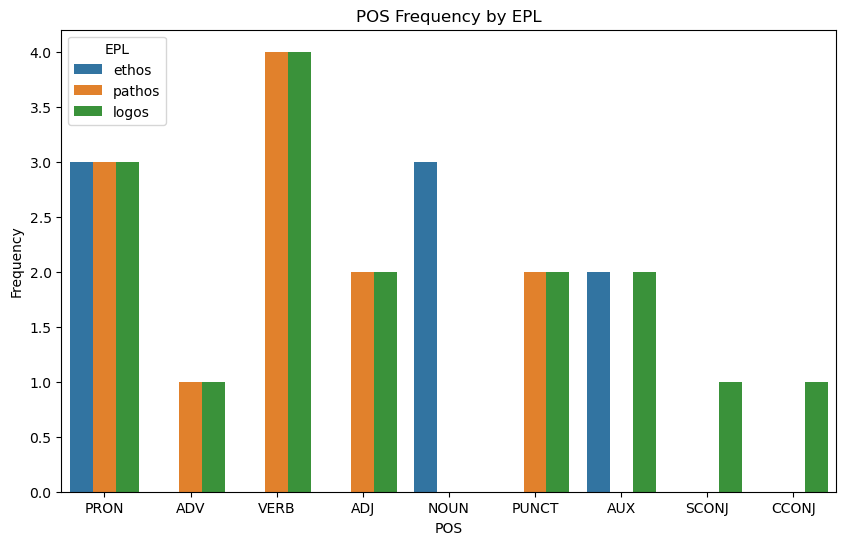

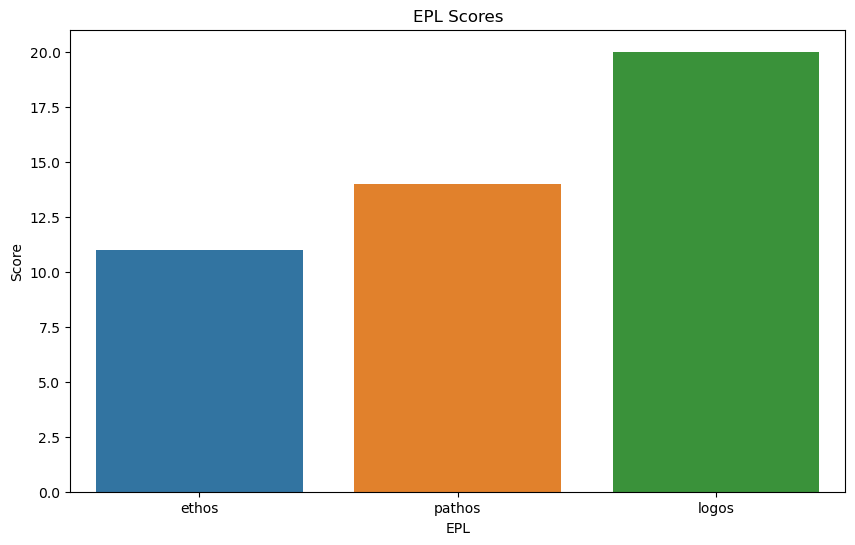

In [33]:

import matplotlib.pyplot as plt
import seaborn as sns


# Updated POS to EPL mapping
scoring_rules = {
    'ADJ': {'ethos': 0, 'pathos': 2, 'logos': 1, 'weight': 1, 'decay': 0.75},  # adjectives
    'ADV': {'ethos': 0, 'pathos': 1, 'logos': 1, 'weight': 0.5, 'decay': 0.75},  # adverbs
    'AUX': {'ethos': 1, 'pathos': 0, 'logos': 1, 'weight': 0.25, 'decay': 0.75},  # auxiliary
    'CCONJ': {'ethos': 0, 'pathos': 0, 'logos': 2, 'weight': 0.75, 'decay': 0.75},  # coordinating conjunction
    'DET': {'ethos': 0, 'pathos': 0, 'logos': 2, 'weight': 0.25, 'decay': 0.75},  # determiner
    'INTJ': {'ethos': 0, 'pathos': 2, 'logos': 0, 'weight': 1, 'decay': 0.75},  # interjection
    'NOUN': {'ethos': 1, 'pathos': 0, 'logos': 0, 'weight': 1, 'decay': 0.75},  # noun
    'NUM': {'ethos': 1, 'pathos': 1, 'logos': 2, 'weight': 0.5, 'decay': 0.75},  # numeral
    'PART': {'ethos': 0, 'pathos': 0, 'logos': 1, 'weight': 0.1, 'decay': 0.75},  # particle
    'PRON': {'ethos': 2, 'pathos': 1, 'logos': 1, 'weight': 1, 'decay': 0.75},  # pronoun
    'PROPN': {'ethos': 2, 'pathos': 1, 'logos': 0, 'weight': 0.5, 'decay': 0.75},  # proper noun
    'PUNCT': {'ethos': 0, 'pathos': 1, 'logos': 2, 'weight': 0.2, 'decay': 0.75},  # punctuation
    'SCONJ': {'ethos': 0, 'pathos': 0, 'logos': 2, 'weight': 0.5, 'decay': 0.75},  # subordinating conjunction
    'SYM': {'ethos': 0, 'pathos': 1, 'logos': 1, 'weight': 0.1, 'decay': 0.75},  # symbol
    'VERB': {'ethos': 0, 'pathos': 1, 'logos': 1, 'weight': 1, 'decay': 0.75},  # verb
    'X': {'ethos': 0, 'pathos': 2, 'logos': 0, 'weight': 0.1, 'decay': 0.75},  # other
}

def pos_frequency(text):
    doc = nlp(text)
    pos_frequency = Counter(token.pos_ for token in doc)

    result = defaultdict(list)
    epl_scores = defaultdict(int)

    for pos, freq in pos_frequency.items():
        epl_score_tuples = scoring_rules.get(pos, [('none', 0)])
        for epl, score in epl_score_tuples:
            result[pos].append((epl, freq))
            epl_scores[epl] += score * freq

    return result, dict(epl_scores)

def pos_to_df(pos_freq, epl_scores):
    data = [(pos, epl, freq) for pos, epl_freq in pos_freq.items() for epl, freq in epl_freq]
    df_pos = pd.DataFrame(data, columns=['POS', 'EPL', 'Frequency'])

    data = [(epl, score) for epl, score in epl_scores.items()]
    df_scores = pd.DataFrame(data, columns=['EPL', 'Score'])

    return df_pos, df_scores

def visualize(df_pos, df_scores):
    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_pos, x='POS', y='Frequency', hue='EPL')
    plt.title('POS Frequency by EPL')
    plt.show()

    plt.figure(figsize=(10, 6))
    sns.barplot(data=df_scores, x='EPL', y='Score')
    plt.title('EPL Scores')
    plt.show()

# Example usage
text = "I really enjoy using artificial intelligence. It's amazing how it can understand language and generate text."

pos_freq, epl_scores = pos_frequency(text)
df_pos, df_scores = pos_to_df(pos_freq, epl_scores)
visualize(df_pos, df_scores)


In [34]:


# Tokenize text into sentences
def tokenize_into_sentences(text):
    doc = nlp(text)
    return [sent.text for sent in doc.sents]

# Create a TF-IDF vectorizer
vectorizer = TfidfVectorizer()

def calculate_tfidf_scores(text):
    # Tokenize the text into sentences
    sentences = tokenize_into_sentences(text)

    # Calculate TF-IDF values for each word in the text
    tfidf_matrix = vectorizer.fit_transform(sentences)
    tfidf_scores = dict(zip(vectorizer.get_feature_names_out(), tfidf_matrix.sum(axis=0).A1))
    
    # Initialize EPL scores
    epl_scores = {'ethos': 0, 'pathos': 0, 'logos': 0}

    # Assign EPL scores based on POS tags of words with high TF-IDF scores
    for word, score in tfidf_scores.items():
        if score > 0.2:  # TF-IDF threshold
            token = nlp(word)[0]
            if token.pos_ in ['NOUN', 'PRON', 'PROPN']:
                epl_scores['ethos'] += 1
            elif token.pos_ in ['VERB', 'ADJ', 'ADV']:
                epl_scores['pathos'] += 1
            elif token.pos_ in ['CONJ', 'DET', 'AUX']:
                epl_scores['logos'] += 1

    return epl_scores

text = "Without further evidence, I would have zero chance of winning."

epl_scores = calculate_tfidf_scores(text)

print(f"EPL scores from TF-IDF: {epl_scores}")

EPL scores from TF-IDF: {'ethos': 2, 'pathos': 3, 'logos': 1}


In [35]:
# POS to EPL mapping
scoring_rules = {
    'ADJ': {'ethos': 0, 'pathos': 2, 'logos': 1, 'weight': 1, 'decay': 0.75},  # adjectives
    'ADV': {'ethos': 0, 'pathos': 1, 'logos': 1, 'weight': 0.5, 'decay': 0.75},  # adverbs
    'AUX': {'ethos': 1, 'pathos': 0, 'logos': 1, 'weight': 0.25, 'decay': 0.75},  # auxiliary
    'CCONJ': {'ethos': 0, 'pathos': 0, 'logos': 2, 'weight': 0.75, 'decay': 0.75},  # coordinating conjunction
    'DET': {'ethos': 0, 'pathos': 0, 'logos': 2, 'weight': 0.25, 'decay': 0.75},  # determiner
    'INTJ': {'ethos': 0, 'pathos': 2, 'logos': 0, 'weight': 1, 'decay': 0.75},  # interjection
    'NOUN': {'ethos': 1, 'pathos': 0, 'logos': 0, 'weight': 1, 'decay': 0.75},  # noun
    'NUM': {'ethos': 1, 'pathos': 1, 'logos': 2, 'weight': 0.5, 'decay': 0.75},  # numeral
    'PART': {'ethos': 0, 'pathos': 0, 'logos': 1, 'weight': 0.1, 'decay': 0.75},  # particle
    'PRON': {'ethos': 2, 'pathos': 1, 'logos': 1, 'weight': 1, 'decay': 0.75},  # pronoun
    'PROPN': {'ethos': 2, 'pathos': 1, 'logos': 0, 'weight': 0.5, 'decay': 0.75},  # proper noun
    'PUNCT': {'ethos': 0, 'pathos': 1, 'logos': 2, 'weight': 0.2, 'decay': 0.75},  # punctuation
    'SCONJ': {'ethos': 0, 'pathos': 0, 'logos': 2, 'weight': 0.5, 'decay': 0.75},  # subordinating conjunction
    'SYM': {'ethos': 0, 'pathos': 1, 'logos': 1, 'weight': 0.1, 'decay': 0.75},  # symbol
    'VERB': {'ethos': 0, 'pathos': 1, 'logos': 1, 'weight': 1, 'decay': 0.75},  # verb
    'X': {'ethos': 0, 'pathos': 2, 'logos': 0, 'weight': 0.1, 'decay': 0.75},  # other
}

def calculate_epl_scores(text):
    # Tokenize the text into sentences
    sentences = tokenize_into_sentences(text)

    # Initialize EPL scores
    epl_scores = {'ethos': 0, 'pathos': 0, 'logos': 0}

    # Assign EPL scores based on POS tags of words with high TF-IDF scores
    for sentence in sentences:
        doc = nlp(sentence)
        pos_counts = defaultdict(int)
        for token in doc:
            pos_counts[token.pos_] += 1
            rule = scoring_rules.get(token.pos_, {})
            for epl, value in rule.items():
                if epl in ['ethos', 'pathos', 'logos']:
                    decayed_value = value * (rule['weight'] * rule['decay'] ** (pos_counts[token.pos_] - 1))
                    epl_scores[epl] += decayed_value

    return epl_scores


In [40]:
calculate_epl_scores("CMV: There is a moral imperative to change and dismantle old cultures and traditions at odds with modern moral values")

{'ethos': 5.2880859375, 'pathos': 8.98125, 'logos': 9.671875}

In [41]:
e_text_sample = "Why are moral rules needed?  For example, why do humans need rules about keeping promises, telling the truth and private property?  This answer should be fairly obvious.  Without such rules people would not be able to live amongst other humans.  People could not make plans, could not leave their belongings behind them wherever they went.  We would not know who to trust and what to expect from others.  Civilized, social life would not be possible.  So, the question is :   Why should humans care about being moral?"
p_text_sample = "If you grew up not understanding your emotions, you might wonder what to do with all these indefinable feelings that seem to get in the way of everything. Learn how to understand your emotions using the emotion wheel deeply."
l_text_sample = "Even when an essay has a clear thesis, and each paragraph in the body has an effective topic sentence, readers may have difficulty understanding and accepting what you have to say if the sentences do not flow smoothly. On the other hand, if your sentences are logically ordered and connected within each paragraph, your readers can easily follow what you are saying."

In [42]:
e_sample_score = calculate_epl_scores(e_text_sample)
p_sample_score = calculate_epl_scores(p_text_sample)
l_sample_score = calculate_epl_scores(l_text_sample)

print(e_sample_score, p_sample_score, l_sample_score)

{'ethos': 25.9912109375, 'pathos': 35.23749999999999, 'logos': 41.29687499999999} {'ethos': 13.451171875, 'pathos': 12.938671874999999, 'logos': 16.726171875} {'ethos': 16.49349594116211, 'pathos': 18.859814453125, 'logos': 27.619482421875002}


In [86]:
core_words_epl = {
    "serenity": {"pathos": 1.75},
    "acceptance": {"ethos": 1.75},
    "apprehension": {"pathos": 1.75},
    "distraction": {"logos": 1.75},
    "pensiveness": {"pathos": 1.75},
    "boredom": {"ethos": 1.75},
    "annoyance": {"pathos": 1.75},
    "interest": {"logos": 1.75},
    "ecstacy": {"pathos": 1.25},
    "admiration": {"ethos": 1.25},
    "terror": {"pathos": 1.25},
    "amazement": {"logos": 1.25},
    "grief": {"pathos": 1.25},
    "loathing": {"ethos": 1.25},
    "rage": {"pathos": 1.25},
    "vigilance": {"logos": 1.25},
    "love": {"pathos": 1.75},
    "submission": {"ethos": 0.875, "pathos": 0.875},
    "awe": {"pathos": 0.875, "logos": 0.875},
    "disapproval": {"logos": 0.875, "pathos": 0.875},
    "remorse": {"pathos": 0.875, "ethos": 0.875},
    "contempt": {"ethos": 0.875, "pathos": 0.875},
    "aggressiveness": {"logos": 0.875, "pathos": 0.875},
    "optimism": {"pathos": 0.875, "logos": 0.875},
}


In [ ]:
import gensim.downloader
from gensim.models import KeyedVectors
from nltk.tokenize import word_tokenize
from scipy.spatial.distance import cosine

# Load pre-trained Word2Vec model (you need to download it first)
word_vectors = gensim.downloader.load('word2vec-google-news-300')

In [70]:
type(word_vectors)

gensim.models.keyedvectors.KeyedVectors

In [97]:
def associate_emotion(text):
    # Tokenize the text
    words = word_tokenize(text)

    # Initialize EPL scores
    scores = {"ethos": 0, "pathos": 0, "logos": 0}

    # For each word in the text
    for word in words:
        # Skip if word not in Word2Vec vocab
        if word not in word_vectors.key_to_index:
            continue

        # Get Word2Vec vector for the word
        word_vector = word_vectors[word]

        # For each core word and its associated concepts
        for core_word, concepts in core_words_epl.items():
            # Skip if core word not in Word2Vec vocab
            if core_word not in word_vectors.key_to_index:
                continue

            # Get Word2Vec vector for the core word
            core_vector = word_vectors[core_word]

            # Calculate cosine similarity between word and core word
            similarity = 1 - cosine(word_vector, core_vector)
            #print(f'Word: {word}, Core Word: {core_word}, Similarity: {similarity}')  # Debug line

            # If similarity is above a threshold (e.g., 0.5)
            if similarity > 0.35:
                # Add weighted scores to EPL scores
                for concept, weight in concepts.items():
                    if concept in scores:
                        scores[concept] += weight * similarity

    return scores


In [108]:
import nltk
nltk.download('averaged_perceptron_tagger')

degree_2_words_epl = {}

# For each core word and its associated EPL values
for core_word, epl_values in core_words_epl.items():
    try:
        # Get top 10 most similar words
        similar_words = word_vectors.most_similar(core_word, topn=10)

        # For each similar word and its similarity score
        for similar_word, _ in similar_words:
            # If the similar word is not already a core word
            if similar_word not in core_words_epl:
                # Exclude words with underscores
                if "_" not in similar_word:
                    # Exclude proper nouns
                    pos_tag = nltk.pos_tag([similar_word])[0][1]
                    if pos_tag != 'NNP' and pos_tag != 'NNPS':  # These are tags for proper nouns
                        # Add the similar word to the 2nd degree word list, with 90% of the original score
                        degree_2_words_epl[similar_word] = {k: v*0.9 for k, v in epl_values.items()}  # Adjusting EPL values here
    except KeyError:
        # Ignore core words that are not in the Word2Vec vocabulary
        continue


[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /Users/pulpdesign/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!


In [110]:
degree_3_words_epl = {}

# For each 2nd degree word and its associated EPL values
for degree_2_word, epl_values in degree_2_words_epl.items():
    try:
        # Get top 20 most similar words
        similar_words = word_vectors.most_similar(degree_2_word, topn=20)

        # For each similar word and its similarity score
        for similar_word, _ in similar_words:
            # If the similar word is not already a 2nd degree or core word
            if similar_word not in degree_2_words_epl and similar_word not in core_words_epl:
                # Exclude words with underscores
                if "_" not in similar_word:
                    # Exclude proper nouns
                    pos_tag = nltk.pos_tag([similar_word])[0][1]
                    if pos_tag != 'NNP' and pos_tag != 'NNPS':  # These are tags for proper nouns
                        # Add the similar word to the 3rd degree word list, with 85% of the original score
                        degree_3_words_epl[similar_word] = {k: v*0.85 for k, v in epl_values.items()}  # Adjusting EPL values here
    except KeyError:
        # Ignore 2nd degree words that are not in the Word2Vec vocabulary
        continue


In [111]:
print(degree_3_words_epl)

{'harmony': {'pathos': 1.3387499999999999}, 'contentment': {'pathos': 1.3387499999999999}, 'peace': {'pathos': 1.3387499999999999}, 'bliss': {'pathos': 1.3387499999999999}, 'idyllic': {'pathos': 1.3387499999999999}, 'placidity': {'pathos': 1.3387499999999999}, 'contemplative': {'pathos': 1.3387499999999999}, 'reverie': {'pathos': 1.3387499999999999}, 'lushness': {'pathos': 1.3387499999999999}, 'hominess': {'pathos': 1.3387499999999999}, 'blissful': {'pathos': 1.3387499999999999}, 'contemplation': {'pathos': 1.3387499999999999}, 'mellowness': {'pathos': 1.3387499999999999}, 'placid': {'pathos': 1.3387499999999999}, 'bucolic': {'pathos': 1.3387499999999999}, 'picturesque': {'pathos': 1.3387499999999999}, 'restful': {'pathos': 1.3387499999999999}, 'verdant': {'pathos': 1.3387499999999999}, 'lush': {'pathos': 1.3387499999999999}, 'sylvan': {'pathos': 1.3387499999999999}, 'idyllically': {'pathos': 1.3387499999999999}, 'pleasant': {'pathos': 1.3387499999999999}, 'aloneness': {'ethos': 1.3387

In [98]:
e_text_sample = "Why are moral rules needed?  For example, why do humans need rules about keeping promises, telling the truth and private property?  This answer should be fairly obvious.  Without such rules people would not be able to live amongst other humans.  People could not make plans, could not leave their belongings behind them wherever they went.  We would not know who to trust and what to expect from others.  Civilized, social life would not be possible.  So, the question is :   Why should humans care about being moral?"
p_text_sample = "If you grew up not understanding your emotions, you might wonder what to do with all these indefinable feelings that seem to get in the way of everything. Learn how to understand your emotions using the emotion wheel deeply."
l_text_sample = "Even when an essay has a clear thesis, and each paragraph in the body has an effective topic sentence, readers may have difficulty understanding and accepting what you have to say if the sentences do not flow smoothly. On the other hand, if your sentences are logically ordered and connected within each paragraph, your readers can easily follow what you are saying."

In [112]:
print(degree_2_words_epl)

{'tranquility': {'pathos': 1.575}, 'quietude': {'pathos': 1.575}, 'serene': {'pathos': 1.575}, 'solitude': {'pathos': 1.575}, 'stillness': {'pathos': 1.575}, 'peacefulness': {'pathos': 1.575}, 'tranquil': {'pathos': 1.575}, 'calmness': {'pathos': 1.575}, 'restfulness': {'pathos': 1.575}, 'quietness': {'pathos': 1.575}, 'Acceptance': {'ethos': 1.575}, 'acceptability': {'ethos': 1.575}, 'recognition': {'ethos': 1.575}, 'acknowledgment': {'ethos': 1.575}, 'approval': {'ethos': 1.575}, 'adoption': {'ethos': 1.575}, 'apprehensions': {'pathos': 1.575}, 'nervousness': {'pathos': 1.575}, 'uneasiness': {'pathos': 1.575}, 'trepidation': {'pathos': 1.575}, 'anxiety': {'pathos': 1.575}, 'fear': {'pathos': 1.575}, 'wariness': {'pathos': 1.575}, 'anxiousness': {'pathos': 1.575}, 'unease': {'pathos': 1.575}, 'misgiving': {'pathos': 1.575}, 'distracting': {'logos': 1.575}, 'distractions': {'logos': 1.575}, 'distracted': {'logos': 1.575}, 'distract': {'logos': 1.575}, 'distracts': {'logos': 1.575}, 'di

In [102]:
print(associate_emotion(p_text_sample), associate_emotion(e_text_sample), associate_emotion(l_text_sample))

{'ethos': 3.0981806442141533, 'pathos': 10.78041161969304, 'logos': 1.311314720660448} {'ethos': 0, 'pathos': 1.3815288245677948, 'logos': 0} {'ethos': 1.6090668886899948, 'pathos': 0.9353407919406891, 'logos': 0}


In [ ]:
print(scoreboard_df.columns)

In [ ]:
def calc_total_turn_score(row):
    total_turn_score = row['base_score'] * row['epl_multiplier']
    return total_turn_score

scoreboard_df['total_turn_score'] = scoreboard_df.apply(calc_total_turn_score, axis=1)

scoreboard_df

In [ ]:
def calc_cumulative_speaker_base_score(df):
    df['cumulative_speaker_base_score'] = df.groupby('speaker')['base_score'].cumsum()
    return df

scoreboard_df = calc_cumulative_speaker_base_score(scoreboard_df)

scoreboard_df

In [ ]:
def calc_cumulative_speaker_total_score(df):
    df['cumulative_speaker_total_score'] = df.groupby('speaker')['total_turn_score'].cumsum()
    return df

scoreboard_df = calc_cumulative_speaker_total_score(scoreboard_df)

scoreboard_df

In [ ]:
def recalculate_all_scores(df):
    scoreboard_df = df
    scoreboard_df['word_count_points'] = scoreboard_df.apply(get_word_count_points, axis=1)
    scoreboard_df['sentence_count_points'] = scoreboard_df.apply(get_sentence_count_points, axis=1)
    scoreboard_df['named_entity_count_points'] = scoreboard_df.apply(get_named_entity_points, axis=1)
    scoreboard_df['named_entities'] = scoreboard_df.apply(get_named_entities, axis=1)
    scoreboard_df['bonus_word_points'] = scoreboard_df.apply(get_word_bonus_points, axis=1)
    scoreboard_df['bonus_word_words'] = scoreboard_df.apply(get_bonus_word_words, axis=1)
    scoreboard_df['base_score'] = scoreboard_df.apply(calc_base_score, axis=1)
    scoreboard_df['epl_multiplier'] = scoreboard_df.apply(calc_epl_multiplier, axis=1)
    scoreboard_df['total_turn_score'] = scoreboard_df.apply(calc_total_turn_score, axis=1)    
    return df


In [ ]:
def parse_content(content):
    # Parse JSON string into a dictionary
    content_dict = json.loads(content)

    # Extract all relevant columns
    relevant_columns = {key: value for key, value in content_dict.items() if key in ['E', 'P', 'L', 'E_Expl', 'P_Expl', 'L_Expl']}

    return relevant_columns

def get_gpt_response(row, api_key):
    openai.api_key = api_key
    response = prompt_epl(row)
    return response


def write_responses_to_file(response, lock1, output_file_full, idx):
    with lock1:
        with open(output_file_full, 'a') as f:
            # Append the index to the response data
            output_data = {
                'index': idx,
                'response': response
            }
            json.dump(output_data, f, indent=4)
            f.write('\n')


def recalculate_scores(df, idx):
    df.loc[idx, 'epl_multiplier'] = 1 + ((float(df.loc[idx, 'E']) + float(df.loc[idx, 'P']) + float(df.loc[idx, 'L'])) / 30)
    df.loc[idx, 'base_score'] = float(df.loc[idx, 'base_score']) 
    df.loc[idx, 'total_turn_score'] = df.loc[idx, 'base_score'] * (1 + (df.loc[idx, 'epl_multiplier']))

    df.loc[idx, 'cumulative_speaker_base_score'] = df[df['speaker'] == df.loc[idx, 'speaker']]['base_score'].sum()
    df.loc[idx, 'cumulative_speaker_total_score'] = df[df['speaker'] == df.loc[idx, 'speaker']]['total_turn_score'].sum()

def extract_and_parse_content(response):
    # Extract 'content' field and parse it to get scores and explanations
    content = response['choices'][0]['message']['content']
    parsed_content = parse_content(content)
    return parsed_content

def update_dataframe_with_parsed_content(df, parsed_content, idx):
    for key, value in parsed_content.items():
        df.loc[idx, key] = value


In [ ]:
def worker(idx, output_file_full, df, lock1, lock2, api_key):
    retries = 5
    for attempt in range(retries):
        try:
            # Get current row
            row = df.loc[idx]

            # Set the API key
            openai.api_key = api_key

            # Call OpenAI API and get response
            response = prompt_epl(row)

            # Extract and parse content
            parsed_content = extract_and_parse_content(response)
            
            # Save the response to file
            write_responses_to_file(response, lock1, output_file_full, idx)

            break

        except Exception as e:
            # If it's the last attempt and it still fails, we print the error and move on to the next task
            if attempt == retries - 1:
                print(f'Error at index {idx} after {retries} attempts: {str(e)}')
                print(f'Response content: {response["choices"][0]["message"]["content"]}')  # Add this line
            else:
                # If it's not the last attempt, we wait for a bit and try again
                time.sleep(2 ** attempt)

    return idx, parsed_content


In [ ]:
def get_epl(input_dataframe, output_file_full, startturn=None, endturn=None, runcount=None):
    # Error checking for parameters
    if startturn is not None and endturn is not None:
        if runcount is not None:
            raise ValueError("Parameter 'runcount' cannot be used together with 'startturn' and 'endturn'. Use 'runcount' alone or with either 'startturn' and 'endturn'.")

    # Determine start and end points for analysis
    start = startturn if startturn is not None else 0
    end = endturn if endturn is not None else len(input_dataframe)

    # Determine number of runs
    if runcount is not None:
        end = min(start + runcount, len(input_dataframe))

    # Check if 'end' exceeds the length of the speaker turns
    if end > len(input_dataframe):
        end = len(input_dataframe)
        print(f"Warning: The end point exceeded the length of the dataframe. It has been adjusted to the last turn: {end}")

    # Create locks for writing to file and dataframe
    lock1 = Lock()
    lock2 = Lock()

    with ThreadPoolExecutor(max_workers=25) as executor:
        # Assign API keys cyclically and start all the tasks
        futures = [executor.submit(worker, i, output_file_full, input_dataframe, lock1, lock2, open_ai_keys[i % len(open_ai_keys)]) for i in range(start, end)]

        # Ensure all threads have finished
        for future in as_completed(futures):
            try:
                # Get the original index from the future
                original_index, parsed_content = future.result()

                # Update DataFrame with new values (with thread lock to avoid race conditions)
                with lock2:
                    update_dataframe_with_parsed_content(input_dataframe, parsed_content, original_index)
            except Exception as e:
                print(f"Error in a thread: {str(e)}")

    # Calculate the cumulative scores after all threads have completed
    for idx in input_dataframe.index:
        recalculate_scores(input_dataframe, idx)

    # Sort DataFrame by 'Turn' after all threads are completed
    input_dataframe.sort_values('turn_number', inplace=True)
    input_dataframe.reset_index(drop=True, inplace=True)

    # Reset openai.api_key to None after the job is done
    openai.api_key = None

    return input_dataframe


In [ ]:
final_scoreboard = get_epl(scoreboard_df, "2008-sep-29-detailed-scoreboard-3-full.json")

In [ ]:
final_scoreboard = recalculate_all_scores(final_scoreboard)
final_scoreboard = calc_cumulative_speaker_base_score(final_scoreboard)
final_scoreboard = calc_cumulative_speaker_total_score(final_scoreboard)

final_scoreboard = final_scoreboard[[
    'speaker',
    'content',
    'turn_number',
    'cumulative_speaker_turn_number',
    'word_count_points',
    'sentence_count_points',
    'named_entity_count_points',
    'named_entities',
    'bonus_word_points',
    'bonus_word_words',
    'base_score',
    'E',
    'P',
    'L',
    'E_Expl',
    'P_Expl',
    'L_Expl',
    'epl_multiplier',
    'total_turn_score',
    'cumulative_speaker_base_score',
    'cumulative_speaker_total_score'
]]

final_scoreboard

In [ ]:
final_scoreboard.shape

(377, 21)

In [ ]:
final_scoreboard.to_csv("sep-29-2008-final-scoreboard-csv-2.csv")

In [ ]:
csv_test = pd.read_csv("sep-29-2008-final-scoreboard-csv-2.csv")

In [ ]:
csv_test.columns

Index(['Unnamed: 0', 'speaker', 'content', 'turn_number',
       'cumulative_speaker_turn_number', 'word_count_points',
       'sentence_count_points', 'named_entity_count_points', 'named_entities',
       'bonus_word_points', 'bonus_word_words', 'base_score', 'E', 'P', 'L',
       'E_Expl', 'P_Expl', 'L_Expl', 'epl_multiplier', 'total_turn_score',
       'cumulative_speaker_base_score', 'cumulative_speaker_total_score'],
      dtype='object')

In [ ]:
csv_test.shape

(377, 22)

In [ ]:

pd.set_option('display.max_colwidth', None)


In [ ]:
csv_test.sort_values('epl_multiplier', ascending=False)

,Unnamed: 0,speaker,content,turn_number,cumulative_speaker_turn_number,word_count_points,sentence_count_points,named_entity_count_points,named_entities,bonus_word_points,bonus_word_words,base_score,E,P,L,E_Expl,P_Expl,L_Expl,epl_multiplier,total_turn_score,cumulative_speaker_base_score,cumulative_speaker_total_score
214,214,OBAMA,"Well, Senator McCain is absolutely right that the earmarks process has been abused, which is why I suspended any requests for my home state, whether it was for senior centers or what have you, until we cleaned it up. And he’s also right that oftentimes lobbyists and special interests are the ones that are introducing these kinds of requests, although that wasn’t the case with me. But let’s be clear: Earmarks account for $18 billion in last year’s budget. Senator McCain is proposing — and this is a fundamental difference between us — $300 billion in tax cuts to some of the wealthiest corporations and individuals in the country, $300 billion. Now, $18 billion is important; $300 billion is really important. And in his tax plan, you would have CEOs of Fortune 500 companies getting an average of $700,000 in reduced taxes, while leaving 100 million Americans out. So my attitude is, we’ve got to grow the economy from the bottom up. What I’ve called for is a tax cut for 95 percent of working families, 95 percent. And that means that the ordinary American out there who’s collecting a paycheck every day, they’ve got a little extra money to be able to buy a computer for their kid, to fill up on this gas that is killing them. And over time, that, I think, is going to be a better recipe for economic growth than the — the policies of President Bush that John McCain wants to — wants to follow.",215,70,302,10,18,"(McCain, $18 billion, last year’s, McCain, $300 billion, $300 billion, $18 billion, $300 billion, Fortune 500, 700,000, 100 million, Americans, 95 percent, 95 percent, American, every day, Bush, John McCain)",120,"{'billion', 'which', 'president', 'think', 'average', 'or', 'percent', 'special', 'than', 'a', 'there', 'able', 'between', 'tax', 'case', 'you', 'ordinary', 'is', 'computer', 'on', 'his', 'recipe', 'it', 'these', 'economic', 'the', 'oftentimes', 'right', 'money', 'difference', 'any', 'senior', 'got', 'gas', 'suspended', 'but', 'day', 'fundamental', 'while', 'so', 'are', 'important', 'account', 'getting', 'million', 'plan', 'going', 'grow', 'working', 'little', 'fortune', 'clear', 'over', 'cut', 'us', 'last', 'now', 'attitude', 'every', 'was', 'out', 'that', 'growth', 'although', 'extra', 't', 'fill', 'better', 'be', 'them', 'follow', 'my', 'state', 'their', 'home', 'buy', 'with', 'up', 'and', 'been', 'leaving', 'bush', 'killing', 'of', 'process', 'me', 'year', 'really', 'what', 'john', 'have', 'bottom', 'they', 'why', 'economy', 'absolutely', 'senator', 'budget', 'who', 'he', 'well', 'until', 'i', 'for', 'an', 'to', 'time', 'we', 'let', 'in', 's', 'this', 'reduced', 'whether', 'would', 'country', 'also', 'american', 'from', 'some'}",450,7.8,8.5,8.3,The speaker establishes credibility by acknowledging the issue with earmarks and his personal actions to suspend requests for his home state.,The speaker uses pathos by mentioning the struggle of ordinary Americans with expenses like gas and their aspiration to provide better opportunities for their children.,The speaker uses logos by contrasting the amount spent on earmarks with the proposed tax cuts for the wealthy and arguing for a more balanced and fair approach to economic growth.,1.820000,819.000000,15742,27110.786667
77,77,OBAMA,"Well, this is an area where Senator McCain and I have a fundamental difference because I think the first question is whether we should have gone into the war in the first place. Now six years ago, I stood up and opposed this war at a time when it was politically risky to do so because I said that not only did we not know how much it was going to cost, what our exit strategy might be, how it would affect our relationships